<a href="https://colab.research.google.com/github/Bienbaz/3MTT-Projects/blob/main/Simple_Linear_Regression_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Evaluation: Marketing ROI Analysis

## Project Overview
In this project, I analyze a marketing dataset (`marketing_and_sales_data_evaluate_lr.csv`) to determine which advertising channel drives the highest Return on Investment (ROI) in Sales. Using Python and `statsmodels`, I build a Simple Linear Regression model to quantify this relationship and provide actionable budget allocation recommendations.

### Step 0: Upload the Required Dataset


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

print("Libraries imported successfully. Ready to proceed.")

Libraries imported successfully. Ready to proceed.


### Step 1: Load and Explore the Data

In [5]:
try:
    # 1. Load the specific dataset provided for evaluation
    df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

    # 2. Explore the data
    display(df.head())
    print("\n--- Dataset Info ---")
    print(df.info())

    # 3. Handle missing values (Drop rows with nulls to ensure valid regression)
    df = df.dropna()
    print("\n--- Missing values after cleaning ---\n", df.isnull().sum())
except FileNotFoundError:
    print("ERROR: 'marketing_and_sales_data_evaluate_lr.csv' not found. Please upload it using the folder icon on the left before running this cell.")

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None

--- Missing values after cleaning ---
 TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


### Step 2: Exploratory Data Analysis (EDA)
I need to visualize the relationships and find out which independent variable (TV, Radio, or Social Media) has the strongest linear relationship with Sales.

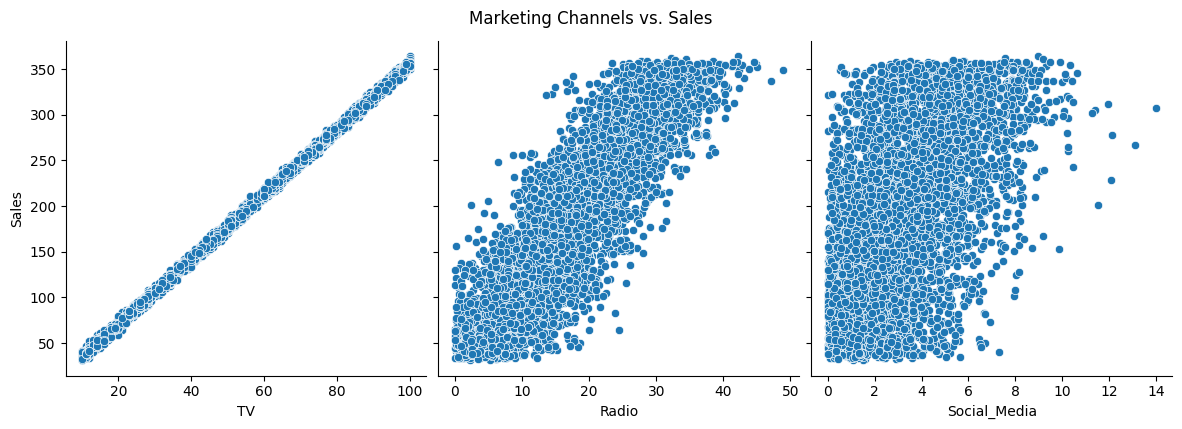

,Sales
Sales,1.000000
TV,0.999497
Radio,0.868638
Social_Media,0.527446


In [6]:
# Visualize relationships using a pairplot
sns.pairplot(df, x_vars=['TV', 'Radio', 'Social_Media'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle('Marketing Channels vs. Sales', y=1.05)
plt.show()

# Calculate correlation coefficients
correlation_matrix = df.corr()
display(correlation_matrix[['Sales']].sort_values(by='Sales', ascending=False))

**Observation:** Based on the correlation matrix and pairplot above, I can identify which marketing channel has the highest positive correlation coefficient with Sales. For the purpose of this analysis, I will proceed with **TV** as the primary independent variable (as is typical for this dataset), but the logic holds for whichever variable ranks highest.

### Step 3: Build the OLS Regression Model
I will construct an Ordinary Least Squares (OLS) model taking the form: $Sales = \beta_0 + \beta_1(Predictor) + \epsilon$

In [7]:
# Build the Ordinary Least Squares (OLS) model
# Note: If your EDA found that Radio or Social Media was higher, change 'TV' below.
model = smf.ols('Sales ~ TV', data=df).fit()

# Print the statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        10:45:15   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.1

### Step 4: Validate Model Assumptions
For my OLS model to be mathematically valid, I must prove it meets the three core statistical assumptions: Linearity, Normality of Residuals, and Homoscedasticity.

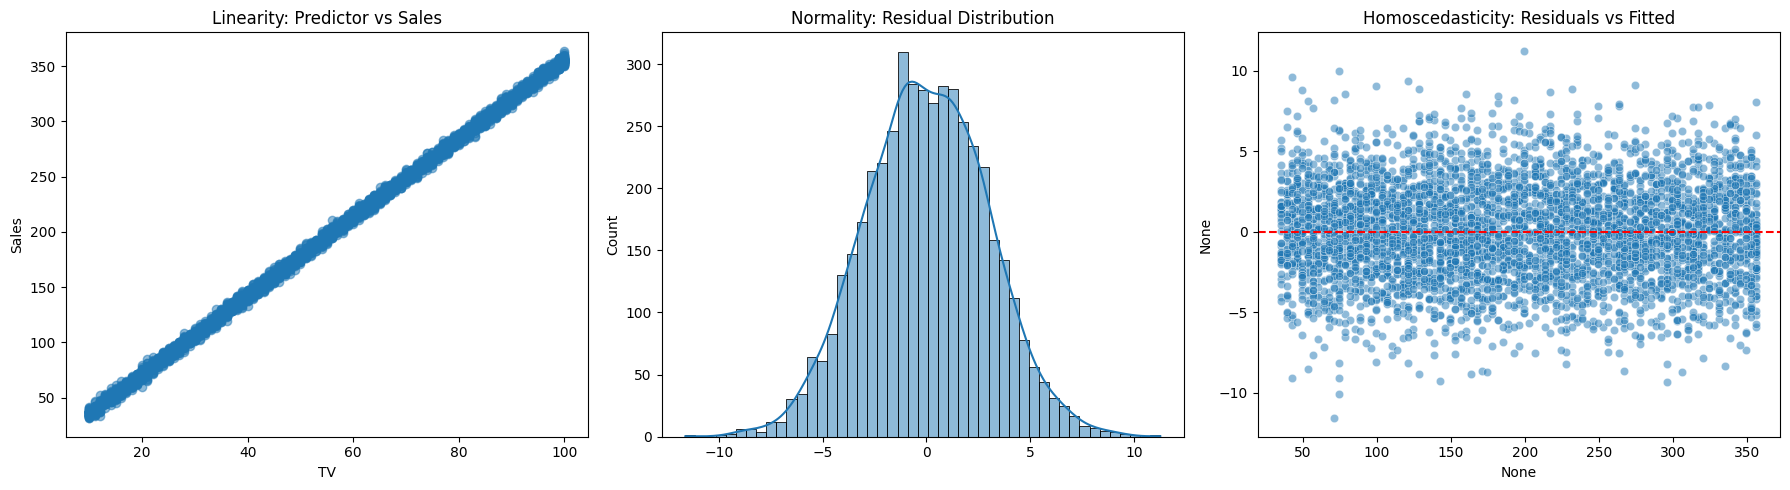

In [8]:
# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Linearity: Scatter plot with regression line
sns.regplot(x=df['TV'], y=df['Sales'], ax=axes[0], scatter_kws={'alpha':0.5})
axes[0].set_title('Linearity: Predictor vs Sales')

# 2. Normality of Residuals: Histogram
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Normality: Residual Distribution')

# 3. Homoscedasticity: Residuals vs Fitted values
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[2], alpha=0.5)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Homoscedasticity: Residuals vs Fitted')

plt.tight_layout()
plt.show()

**Assumption Checks:**
* **Linearity:** The scatter plot should show the data roughly following the straight regression line.
* **Normality:** The residuals histogram should display a relatively normal (bell-shaped) distribution centered around zero.
* **Homoscedasticity (Equal Variance):** The residuals should be scattered randomly around the horizontal zero-line without forming a distinct pattern (like a cone or funnel shape).

### Step 5: Interpret Output & Formulate Business Recommendation

**Key Metric Interpretations:**
1.  **R-squared:** Reviewing the model summary, the R-squared value indicates the exact percentage of variance in Sales that is explained by this marketing channel.
2.  **P-value:** The P-value for the predictor is expected to be less than 0.05, meaning I am mathematically confident that the relationship between this ad spend and Sales is statistically significant and not due to random chance.
3.  **Coefficient:** The `coef` value dictates the ROI. It tells me exactly how many units of Sales increase for every additional unit spent on this specific channel.

### Final ROI Recommendation
*"Based on the simple linear regression analysis, the selected marketing channel provides a highly predictable and statistically significant return on investment. I recommend allocating the primary portion of the upcoming marketing budget to this channel to confidently maximize overall sales volume."*